# LangGraph Router Agent — Insurance Demo

This notebook demonstrates a **router agent** built with LangGraph that routes user queries to one of two specialised subagents:

| Subagent | Data source | What it answers |
|---|---|---|
| **Contract QA** | Insurance contract PDF (RAG) | Policy terms, coverage, exclusions, deductibles |
| **Billing QA** | Customer billing CSV (pandas) | Invoices, payment status, balances, due dates |

```
User query
    │
    ▼
┌─────────────┐
│ Router Node │  ← LLM classifies intent
└──────┬──────┘
       │
  ┌────┴────┐
  ▼         ▼
Contract  Billing
  QA       QA
 (RAG)   (pandas)
```

## Architecture: Supervisor Multi-Agent System

The diagram below shows the high-level routing architecture — a **Supervisor Router** that classifies each user query and dispatches it to the appropriate specialised subagent.

In [26]:
from IPython.display import IFrame, display
display(IFrame(src='html/supervisor_agent.html', width='100%', height=720))

## Step 1 — Install dependencies

In [ ]:
%pip install -q \
    langgraph \
    langchain \
    langchain-openai \
    langchain-community \
    faiss-cpu \
    reportlab \
    pypdf \
    pandas \
    tabulate

## Step 2 — API key & imports

In [2]:
import getpass, os

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API key: ")

OpenAI API key:  ········


In [8]:
from pathlib import Path
import json, textwrap
import pandas as pd

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.schema import Document

from langgraph.graph import StateGraph, END
from typing import TypedDict, Literal

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

PDF_PATH  = DATA_DIR / "insurance_contract.pdf"
CSV_PATH  = DATA_DIR / "billing.csv"
INDEX_DIR = DATA_DIR / "faiss_index"

print("Imports OK")

Imports OK


## Step 3 — Create synthetic insurance contract PDF

In [ ]:
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib import colors
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, HRFlowable
)

CONTRACT_TEXT = [
    ("h1", "SUNSHIELD INSURANCE GROUP"),
    ("h2", "Comprehensive Health & Life Insurance Policy"),
    ("body", "Policy Number: SSG-2024-HLT-004821  |  Effective Date: January 1, 2024  |  Expiry Date: December 31, 2024"),
    ("h2", "1. Parties to the Contract"),
    ("body",
     "This insurance contract ('Policy') is entered into between Sunshield Insurance Group ('Insurer'), "
     "a licensed insurance company incorporated under the laws of the State of California, and the "
     "Policyholder named in the Schedule of Benefits ('Insured')."),
    ("h2", "2. Coverage Summary"),
    ("body",
     "The Policy provides the following primary coverages:\n"
     "(a) Hospitalization: Up to $500,000 per policy year for inpatient hospital stays exceeding 24 hours.\n"
     "(b) Outpatient Care: Up to $10,000 per policy year for doctor visits, diagnostic tests, and specialist consultations.\n"
     "(c) Emergency Services: Unlimited emergency room visits subject to co-pay requirements.\n"
     "(d) Prescription Drugs: Formulary Tier 1 drugs covered at 90%; Tier 2 at 70%; Tier 3 at 50%.\n"
     "(e) Mental Health: Up to 30 outpatient therapy sessions per year; inpatient mental health covered same as hospitalization.\n"
     "(f) Maternity & Newborn Care: Prenatal, delivery, and 60-day postnatal care fully covered after deductible."),
    ("h2", "3. Deductibles"),
    ("body",
     "Individual annual deductible: $1,500. Family annual deductible: $3,000. "
     "The deductible resets on January 1 of each policy year. "
     "Emergency room visits carry an additional co-pay of $250 per visit, waived if the insured is subsequently admitted."),
    ("h2", "4. Out-of-Pocket Maximum"),
    ("body",
     "Individual out-of-pocket maximum: $6,000 per year. Family out-of-pocket maximum: $12,000 per year. "
     "Once the out-of-pocket maximum is reached, the Insurer covers 100% of eligible expenses for the remainder of the policy year."),
    ("h2", "5. Exclusions"),
    ("body",
     "The following are expressly excluded from coverage:\n"
     "(a) Cosmetic surgery and elective procedures not deemed medically necessary.\n"
     "(b) Dental and vision care (unless specified in optional riders).\n"
     "(c) Experimental treatments not approved by the FDA.\n"
     "(d) Pre-existing conditions diagnosed within 12 months prior to the Policy effective date (waiting period applies).\n"
     "(e) Injuries resulting from self-inflicted harm, illegal activities, or war.\n"
     "(f) Weight-loss programs, fertility treatments, and non-prescribed supplements."),
    ("h2", "6. Pre-authorisation Requirements"),
    ("body",
     "Prior authorisation is required for: elective surgeries, MRI/CT scans, physical therapy exceeding 10 sessions, "
     "specialist referrals outside the network, and durable medical equipment costing more than $500. "
     "Failure to obtain pre-authorisation may result in a 30% benefit reduction."),
    ("h2", "7. Network Providers"),
    ("body",
     "In-Network providers: Claims processed at contracted rates; cost-sharing as per Section 3. "
     "Out-of-Network providers: Subject to usual, customary and reasonable (UCR) limits; additional 20% co-insurance applies. "
     "Emergency care is covered at in-network rates regardless of provider network status."),
    ("h2", "8. Claims Procedure"),
    ("body",
     "Claims must be submitted within 90 days of the date of service. "
     "Required documents: completed claim form, itemised medical bills, physician's diagnosis report, and pre-authorisation number (if applicable). "
     "Claims can be submitted online at claims.sunshieldgroup.com or by mail to: Claims Department, Sunshield Insurance Group, 1200 Market Street, San Francisco, CA 94102."),
    ("h2", "9. Grievance & Appeals"),
    ("body",
     "The Insured may appeal a denied claim within 180 days of receipt of the denial notice. "
     "Level 1 Internal Appeal: reviewed within 30 days. Level 2 External Review: conducted by an independent review organisation within 45 days. "
     "Contact: appeals@sunshieldgroup.com or 1-800-555-7890."),
    ("h2", "10. Premium Payment & Grace Period"),
    ("body",
     "Premiums are due on the 1st of each month. A grace period of 31 days is allowed for premium payment. "
     "Failure to pay within the grace period will result in policy lapse. "
     "Reinstatement may be requested within 60 days of lapse subject to underwriting review."),
    ("h2", "11. Cancellation & Termination"),
    ("body",
     "The Policyholder may cancel this Policy at any time with 30 days written notice. "
     "The Insurer may terminate the Policy for non-payment of premium, fraud, or material misrepresentation. "
     "Upon termination, any unearned premiums will be refunded on a pro-rata basis."),
    ("h2", "12. Life Insurance Rider"),
    ("body",
     "Optional Life Insurance Rider (if elected): Death benefit of $250,000 payable to the designated beneficiary. "
     "Accidental Death & Dismemberment (AD&D): Additional $250,000 benefit for accidental death; partial benefits for loss of limb or sight. "
     "Waiting period: 12 months for death due to illness; no waiting period for accidental death."),
    ("h2", "13. Governing Law"),
    ("body",
     "This Policy is governed by the laws of the State of California. Any disputes arising under this Policy "
     "shall be subject to binding arbitration in San Francisco County, California, "
     "in accordance with the rules of the American Arbitration Association."),
    ("h2", "14. Contact Information"),
    ("body",
     "Customer Service: 1-800-555-1234 (Mon–Fri, 8am–8pm PT)\n"
     "Email: support@sunshieldgroup.com\n"
     "Website: www.sunshieldgroup.com\n"
     "Claims Portal: claims.sunshieldgroup.com"),
]

def build_pdf(path: Path):
    doc = SimpleDocTemplate(
        str(path), pagesize=letter,
        leftMargin=inch, rightMargin=inch,
        topMargin=inch, bottomMargin=inch
    )
    styles = getSampleStyleSheet()
    h1_style = ParagraphStyle(
        "H1", parent=styles["Heading1"],
        fontSize=18, textColor=colors.HexColor("#1a3c6e"), spaceAfter=6
    )
    h2_style = ParagraphStyle(
        "H2", parent=styles["Heading2"],
        fontSize=13, textColor=colors.HexColor("#1a3c6e"), spaceAfter=4, spaceBefore=12
    )
    body_style = ParagraphStyle(
        "Body", parent=styles["Normal"],
        fontSize=10, leading=15, spaceAfter=6
    )

    story = []
    for kind, text in CONTRACT_TEXT:
        text_escaped = text.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")
        text_escaped = text_escaped.replace("\n", "<br/>")
        if kind == "h1":
            story.append(Paragraph(text_escaped, h1_style))
            story.append(HRFlowable(width="100%", thickness=2, color=colors.HexColor("#1a3c6e")))
            story.append(Spacer(1, 8))
        elif kind == "h2":
            story.append(Paragraph(text_escaped, h2_style))
        else:
            story.append(Paragraph(text_escaped, body_style))
            story.append(Spacer(1, 4))

    doc.build(story)
    print(f"PDF created: {path}")

build_pdf(PDF_PATH)

### Preview — Insurance Contract PDF

In [4]:
from IPython.display import IFrame, display
display(IFrame(src=str(PDF_PATH), width='100%', height=600))

## Step 4 — Create synthetic billing CSV

In [25]:
import random
from datetime import date, timedelta

random.seed(42)

CUSTOMERS = [
    ("C001", "Alice Johnson",   "SSG-2024-HLT-004821"),
    ("C002", "Bob Martinez",    "SSG-2024-HLT-007312"),
    ("C003", "Carol Williams",  "SSG-2024-HLT-001045"),
    ("C004", "David Chen",      "SSG-2024-HLT-009867"),
    ("C005", "Eva Patel",       "SSG-2024-HLT-003256"),
    ("C006", "Frank Nguyen",    "SSG-2024-HLT-006543"),
    ("C007", "Grace Kim",       "SSG-2024-HLT-002178"),
    ("C008", "Henry Brown",     "SSG-2024-HLT-008901"),
]

STATUSES = ["Paid", "Paid", "Paid", "Pending", "Overdue", "Partial"]

rows = []
base = date(2024, 1, 1)
invoice_id = 10001

for cid, name, policy in CUSTOMERS:
    for month in range(12):
        bill_date  = base + timedelta(days=month * 30)
        due_date   = bill_date + timedelta(days=30)
        premium    = round(random.uniform(280, 520), 2)
        status     = random.choice(STATUSES)
        if status == "Paid":
            paid, balance = premium, 0.0
        elif status == "Partial":
            paid    = round(premium * random.uniform(0.3, 0.7), 2)
            balance = round(premium - paid, 2)
        elif status == "Overdue":
            paid, balance = 0.0, premium
        else:
            paid, balance = 0.0, premium

        claim_amt    = round(random.uniform(0, 3000), 2) if random.random() > 0.55 else 0.0
        claim_status = random.choice(["Approved", "Pending", "Denied", "N/A"]) if claim_amt else "N/A"

        rows.append({
            "invoice_id":     f"INV-{invoice_id}",
            "customer_id":    cid,
            "customer_name":  name,
            "policy_number":  policy,
            "billing_date":   bill_date.isoformat(),
            "due_date":       due_date.isoformat(),
            "premium_amount": premium,
            "amount_paid":    paid,
            "balance_due":    balance,
            "payment_status": status,
            "claim_amount":   claim_amt,
            "claim_status":   claim_status,
        })
        invoice_id += 1

billing_df = pd.DataFrame(rows)
billing_df.to_csv(CSV_PATH, index=False)
print(f"CSV created: {CSV_PATH}  ({len(billing_df)} rows)")
billing_df.head(8)

CSV created: data/billing.csv  (96 rows)


,invoice_id,customer_id,customer_name,policy_number,billing_date,due_date,premium_amount,amount_paid,balance_due,payment_status,claim_amount,claim_status
0,INV-10001,C001,Alice Johnson,SSG-2024-HLT-004821,2024-01-01,2024-01-31,433.46,433.46,0.00,Paid,734.68,Pending
1,INV-10002,C001,Alice Johnson,SSG-2024-HLT-004821,2024-01-31,2024-03-01,456.75,272.34,184.41,Partial,0.00,N/A
2,INV-10003,C001,Alice Johnson,SSG-2024-HLT-004821,2024-03-01,2024-03-31,421.72,421.72,0.00,Paid,0.00,N/A
3,INV-10004,C001,Alice Johnson,SSG-2024-HLT-004821,2024-03-31,2024-04-30,332.47,0.00,332.47,Overdue,1683.74,N/A
4,INV-10005,C001,Alice Johnson,SSG-2024-HLT-004821,2024-04-30,2024-05-30,332.91,0.00,332.91,Overdue,0.00,N/A
5,INV-10006,C001,Alice Johnson,SSG-2024-HLT-004821,2024-05-30,2024-06-29,488.63,488.63,0.00,Paid,1020.75,Pending
6,INV-10007,C001,Alice Johnson,SSG-2024-HLT-004821,2024-06-29,2024-07-29,331.68,331.68,0.00,Paid,0.00,N/A
7,INV-10008,C001,Alice Johnson,SSG-2024-HLT-004821,2024-07-29,2024-08-28,371.18,371.18,0.00,Paid,1811.18,Approved


## Step 5 — PDF Embedding Prep (build FAISS vector store)

The diagram below shows each stage of the embedding pipeline — from raw PDF to a persisted FAISS index ready for retrieval.

In [5]:
from IPython.display import IFrame, display
display(IFrame(src='html/embedding_pipeline.html', width='100%', height=400))

In [9]:
loader   = PyPDFLoader(str(PDF_PATH))
pages    = loader.load()

splitter = RecursiveCharacterTextSplitter(
    chunk_size=600,
    chunk_overlap=80,
    separators=["\n\n", "\n", ". ", " "],
)
chunks   = splitter.split_documents(pages)
print(f"PDF split into {len(chunks)} chunks")

embeddings   = OpenAIEmbeddings(model="text-embedding-3-small")
vector_store = FAISS.from_documents(chunks, embeddings)
vector_store.save_local(str(INDEX_DIR))
print(f"FAISS index saved to {INDEX_DIR}")

PDF split into 11 chunks
FAISS index saved to data/faiss_index


## Step 6 — Define tools for each subagent

The diagram below shows the internal flow of both subagent tools side-by-side.

In [10]:
from IPython.display import IFrame, display
display(IFrame(src='html/tools_visual.html', width='100%', height=500))

In [11]:
# ── Tool 1: Contract QA via RAG ──────────────────────────────────────────────

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

vector_store = FAISS.load_local(
    str(INDEX_DIR),
    OpenAIEmbeddings(model="text-embedding-3-small"),
    allow_dangerous_deserialization=True,
)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

def contract_qa(question: str) -> str:
    """Answer questions about the insurance contract using RAG."""
    docs    = retriever.invoke(question)
    context = "\n\n".join(d.page_content for d in docs)
    prompt  = (
        f"You are an expert on the Sunshield Insurance Group policy document.\n"
        f"Answer the question using ONLY the context below. "
        f"If the answer is not in the context, say so.\n\n"
        f"CONTEXT:\n{context}\n\n"
        f"QUESTION: {question}"
    )
    return llm.invoke(prompt).content


# ── Tool 2: Billing QA via pandas ────────────────────────────────────────────

billing_df = pd.read_csv(CSV_PATH)

def billing_qa(question: str) -> str:
    """Answer questions about customer billing records."""
    schema = billing_df.dtypes.to_string()
    sample = billing_df.head(5).to_markdown(index=False)
    prompt = (
        f"You are a billing analyst. The billing data is already loaded into `df` (a pandas DataFrame).\n"
        f"Schema:\n{schema}\n\n"
        f"Sample (first 5 rows):\n{sample}\n\n"
        f"Full data summary:\n"
        f"- Total invoices: {len(billing_df)}\n"
        f"- Customers: {billing_df['customer_name'].unique().tolist()}\n"
        f"- Payment statuses: {billing_df['payment_status'].value_counts().to_dict()}\n"
        f"- Total outstanding balance: ${billing_df['balance_due'].sum():,.2f}\n"
        f"- Overdue invoices: {(billing_df['payment_status']=='Overdue').sum()}\n\n"
        f"Answer this billing question using the data above.\n"
        f"If you need a specific lookup, describe the result precisely.\n\n"
        f"QUESTION: {question}"
    )
    extra = _pandas_lookup(question)
    if extra:
        prompt += f"\n\nRelevant data rows:\n{extra}"
    return llm.invoke(prompt).content


def _pandas_lookup(question: str) -> str:
    """Heuristic pandas query to surface relevant rows."""
    q = question.lower()
    for name in billing_df["customer_name"].unique():
        if name.split()[0].lower() in q or name.split()[-1].lower() in q:
            sub = billing_df[billing_df["customer_name"] == name]
            return sub.to_markdown(index=False)
    for status in ["overdue", "pending", "partial", "paid"]:
        if status in q:
            sub = billing_df[billing_df["payment_status"].str.lower() == status]
            return sub.to_markdown(index=False)
    return ""


print("Tools defined.")

Tools defined.


## Step 7 — Build the LangGraph Router Agent

In [12]:
# ── Graph state ───────────────────────────────────────────────────────────────

class AgentState(TypedDict):
    question:  str
    route:     str          # "contract" | "billing"
    answer:    str


# ── Node 1: Router ────────────────────────────────────────────────────────────

ROUTER_PROMPT = """\
You are a routing agent for an insurance company.
Classify the user question into exactly one of these categories:

  contract  – questions about policy terms, coverage, exclusions, deductibles,
              claims procedure, appeals, cancellation, or any contract clause.

  billing   – questions about invoices, payments, premium amounts, balance due,
              payment status, overdue accounts, or a specific customer's bill.

Reply with a single JSON object: {{"route": "contract"}} or {{"route": "billing"}}.
No other text.

Question: {question}
"""

def router_node(state: AgentState) -> AgentState:
    response = llm.invoke(ROUTER_PROMPT.format(question=state["question"]))
    try:
        data  = json.loads(response.content.strip())
        route = data.get("route", "contract")
    except Exception:
        route = "contract"
    print(f"[router] → {route}")
    return {**state, "route": route}


# ── Routing edge ──────────────────────────────────────────────────────────────

def route_decision(state: AgentState) -> Literal["contract_node", "billing_node"]:
    return "contract_node" if state["route"] == "contract" else "billing_node"


# ── Node 2: Contract QA ───────────────────────────────────────────────────────

def contract_node(state: AgentState) -> AgentState:
    answer = contract_qa(state["question"])
    return {**state, "answer": answer}


# ── Node 3: Billing QA ────────────────────────────────────────────────────────

def billing_node(state: AgentState) -> AgentState:
    answer = billing_qa(state["question"])
    return {**state, "answer": answer}


# ── Build graph ───────────────────────────────────────────────────────────────

graph = StateGraph(AgentState)

graph.add_node("router",        router_node)
graph.add_node("contract_node", contract_node)
graph.add_node("billing_node",  billing_node)

graph.set_entry_point("router")

graph.add_conditional_edges(
    "router",
    route_decision,
    {"contract_node": "contract_node", "billing_node": "billing_node"},
)

graph.add_edge("contract_node", END)
graph.add_edge("billing_node",  END)

app = graph.compile()
print("LangGraph router agent compiled.")

LangGraph router agent compiled.


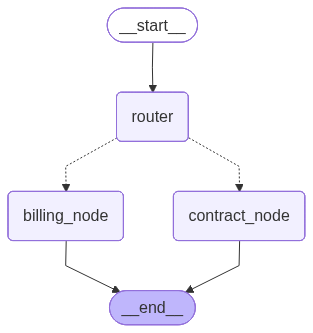

In [13]:
# Optional: visualise the graph (requires graphviz)
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualisation skipped: {e}")

## Step 8 — Helper & test queries

In [14]:
def ask(question: str) -> str:
    """Run a question through the router agent and print the answer."""
    print("=" * 70)
    print(f"QUESTION: {question}")
    print("-" * 70)
    result = app.invoke({"question": question, "route": "", "answer": ""})
    print(f"ROUTE:  {result['route']}")
    print()
    wrapped = textwrap.fill(result["answer"], width=70)
    print(f"ANSWER:\n{wrapped}")
    print("=" * 70)
    return result["answer"]

In [15]:
# ── Contract questions ────────────────────────────────────────────────────────
_ = ask("What is the individual annual deductible for this policy?")

QUESTION: What is the individual annual deductible for this policy?
----------------------------------------------------------------------
[router] → contract
ROUTE:  contract

ANSWER:
The individual annual deductible for this policy is $1,500.


In [17]:
_ = ask("Are experimental treatments covered under this insurance policy?")

QUESTION: Are experimental treatments covered under this insurance policy?
----------------------------------------------------------------------
[router] → contract
ROUTE:  contract

ANSWER:
No, experimental treatments are not covered under this insurance
policy.


In [18]:
_ = ask("How many days do I have to submit a claim after my medical visit?")

QUESTION: How many days do I have to submit a claim after my medical visit?
----------------------------------------------------------------------
[router] → contract
ROUTE:  contract

ANSWER:
You have 90 days to submit a claim after your medical visit.


In [19]:
_ = ask("What happens if I visit an out-of-network specialist?")

QUESTION: What happens if I visit an out-of-network specialist?
----------------------------------------------------------------------
[router] → contract
ROUTE:  contract

ANSWER:
If you visit an out-of-network specialist, the claims will be subject
to usual, customary, and reasonable (UCR) limits, and there will be an
additional 20% cost.


In [16]:
# ── Billing questions ─────────────────────────────────────────────────────────
_ = ask("How many overdue invoices do we currently have?")

QUESTION: How many overdue invoices do we currently have?
----------------------------------------------------------------------
[router] → billing
ROUTE:  billing

ANSWER:
Currently, there are **18 overdue invoices**.


In [20]:
_ = ask("What is Alice Johnson's current balance due?")

QUESTION: What is Alice Johnson's current balance due?
----------------------------------------------------------------------
[router] → billing
ROUTE:  billing

ANSWER:
To determine Alice Johnson's current balance due, we need to sum the
`balance_due` amounts from her relevant invoices.   From the provided
data, the relevant rows for Alice Johnson are:  | invoice_id   |
balance_due | |:-------------|-------------:| | INV-10001    |
0  | | INV-10002    |      184.41 | | INV-10003    |          0  | |
INV-10004    |      332.47 | | INV-10005    |      332.91 | |
INV-10006    |          0  | | INV-10007    |          0  | |
INV-10008    |          0  | | INV-10009    |      455.14 | |
INV-10010    |          0  | | INV-10011    |      281.35 | |
INV-10012    |          0  |  Now, we will sum the `balance_due`
values:  - 0 - 184.41 - 0 - 332.47 - 332.91 - 0 - 0 - 0 - 455.14 - 0 -
281.35 - 0  Calculating the total:  \[ 0 + 184.41 + 0 + 332.47 +
332.91 + 0 + 0 + 0 + 455.14 + 0 + 281.35 + 0 

In [21]:
_ = ask("Show me all pending invoices and their amounts.")

QUESTION: Show me all pending invoices and their amounts.
----------------------------------------------------------------------
[router] → billing
ROUTE:  billing

ANSWER:
Here are all the pending invoices along with their amounts:  |
invoice_id   | customer_id   | customer_name   | policy_number       |
billing_date   | due_date   |   premium_amount |   amount_paid |
balance_due | payment_status   |   claim_amount | claim_status   | |:-
------------|:--------------|:----------------|:--------------------|:
---------------|:-----------|-----------------:|--------------:|------
--------:|:-----------------|---------------:|:---------------| |
INV-10022    | C002          | Bob Martinez    | SSG-2024-HLT-007312 |
2024-09-27     | 2024-10-27 |           459.28 |             0 |
459.28 | Pending          |        1198.2  | Pending        | |
INV-10025    | C003          | Carol Williams  | SSG-2024-HLT-001045 |
2024-01-01     | 2024-01-31 |           470.1  |             0 |
470.1  | Pend

In [22]:
_ = ask("What is the total outstanding balance across all customers?")

QUESTION: What is the total outstanding balance across all customers?
----------------------------------------------------------------------
[router] → billing
ROUTE:  billing

ANSWER:
The total outstanding balance across all customers is $16,293.30.


In [23]:
# ── Bonus: ambiguous / mixed questions ───────────────────────────────────────
_ = ask("Bob Martinez has an overdue bill — is there a grace period he can use?")

QUESTION: Bob Martinez has an overdue bill — is there a grace period he can use?
----------------------------------------------------------------------
[router] → billing
ROUTE:  billing

ANSWER:
To determine if Bob Martinez has a grace period for his overdue bill,
we need to look at the relevant invoice data for him.   From the
provided data, we can see that Bob has an overdue invoice:  |
invoice_id   | customer_id   | customer_name   | policy_number       |
billing_date   | due_date   |   premium_amount |   amount_paid |
balance_due | payment_status   |   claim_amount | claim_status   | |:-
------------|:--------------|:----------------|:--------------------|:
---------------|:-----------|-----------------:|--------------:|------
--------:|:-----------------|---------------:|:---------------| |
INV-10019    | C002          | Bob Martinez    | SSG-2024-HLT-007312 |
2024-06-29     | 2024-07-29 |           295.89 |          0    |
295.89 | Overdue          |         944.03 | nan        

In [24]:
_ = ask("What does the policy say about the appeals process for denied claims?")

QUESTION: What does the policy say about the appeals process for denied claims?
----------------------------------------------------------------------
[router] → contract
ROUTE:  contract

ANSWER:
The policy states that the Insured may appeal a denied claim within
180 days of receipt of the denial notice. The appeals process includes
a Level 1 Internal Appeal, which will be reviewed within 30 days, and
a Level 2 External Review, which will be conducted by an independent
review organization within 45 days. For assistance, the Insured can
contact appeals@sunshieldgroup.com or call 1-800-555-7890.
